# Exercício Computacional 1 - Aritmética de Ponto Flutuante e Eliminação de Gauss



---




**Data de entrega:** Até 07 de Maio de 2023

**Como entregar:** Enviar o jupyter notebook (arquivo .ipynb) pelo pelo próprio Classroom.


**Leia com atenção:**


*   Você deve fazer obrigatoriamente todas as atividades marcadas com a exclamação❗.
*   Atividades marcadas com 🧩 são opcionais, mas interessantes, podendo ser desafiadoras. 
*   Faça uma cópia do notebook para o seu Google Drive e use o Google Colab para executar o notebook e fazer a tarefa.
*   A atividade vai ser baseada no seu número USP para que as soluções dos alunos fiquem diferentes. 
*   Há questões dissertativas!
*   Siga o passo a passo indicado no tutorial, respondendo às atividades propostas no seu jupyter notebook.
*   O notebook que entregar deve estar 100% funcional, isto é, todos os códigos rodando no Colab sem erros. 
*   Você deverá entregar apenas uma cópia do jupyter notebook (.ipynb) no Classroom, na funcionalidade de "entregar" do Classroom. 
*   Foi estimado um tempo total aproximado de 2-3 horas para realização completa da atividade.
*   Esta tarefa é individual e haverá controle de similaridade. Tentativas de cópias, fraude, compra-venda de EPs não serão toleradas, levando a nota zero na tarefa e posterior análise para medidas cabíveis.
*   ❗Exercício 0:❗ Para mostrar que você leu até aqui, escreva seu nome completo (assinatura) na linha a seguir:





*Assinatura:* Danilo Cho

> Bloco com recuo





---





Primeiro vamos carregar algumas bibliotecas: Numpy, Scipy Linear Algebra (scipy.linalg), System (sys) e Time (time)

Agora vamos definir alguns números especiais ("magic") para cada aluno, com base no seu número USP

In [2]:
import numpy as np
import scipy.linalg as la 
import sys
import time

In [3]:
# Coloque aqui o seu número USP
nusp = 10769448

Estes números serão importantes para a atividade:

In [ ]:
magic_ilong = int(str(nusp).replace("0",""))
magic_ishort = int(str(magic_ilong)[:2])
print("magic_ilong  =", magic_ilong)
print("magic_ishort =", magic_ishort)



---




## Aritmética de Ponto Flutuante

Começamos esse tutorial discutindo um pouco de aritmética de ponto flutuante, que vamos definir mais adiante.



Algumas referências:

[1]https://en.wikipedia.org/wiki/IEEE_754

[2] https://betterprogramming.pub/floating-point-numbers-are-weird-in-python-heres-how-to-fix-them-51336e4ad51a

[3] https://ironpython-test.readthedocs.io/en/latest/tutorial/floatingpoint.html


A matemática está furada no computador?

In [5]:
a = 10
b = 0.1
c = 0.2

In [6]:
r1 = a*(b + c)
r2 = a*b + a*c

r1 e r2 deveriam ser iguais...Mas...

In [7]:
print(r1 == r2)

False


In [8]:
print(r1, r2)

3.0000000000000004 3.0


A distributiva e associatividade não valem no computador ?!?!

In [9]:
.2 + .2 + .2 == 0.6

False

In [ ]:
sum = 0.0
n = 10
for i in range(n):
    sum += 1/n
print(sum)

0.9999999999999999


Vamos tentar entender os motivos partindo bem do princípio: como o computador representa os números!

### Números inteiros no computador

Suponha que tenho apenas 3 bits para representar inteiros (ignore o sinal). Ou seja, temos os números binários
000, 001, 011, 100, 110, ..., 111
que representam respectivamente
0, 1, 2, 3, 4, 5, ..., 7
sendo 7 o maior número que conseguimos representar.

Vejamos isso em Python:

In [ ]:
a = 5
b = 6

In [ ]:
bin_a=bin(a)
bin_b=bin(b)
print(a, bin_a)
print(b, bin_b)

5 0b101
6 0b110


Os dois números estão bem representados, mas...

In [ ]:
print(a+b, bin(a+b))

11 0b1011


isso não é representável em 3 bits (o Python, espertinho, percebeu isso e então colocou mais um bit para representar o número 11...).

Em um computador moderno teríamos 64bits para representar um inteiro, e um sinal para carregar.

Veja aqui mais detalhes: https://prof-thiagooliveira.netlify.app/post/signed-and-unsigned-binary-numbers/

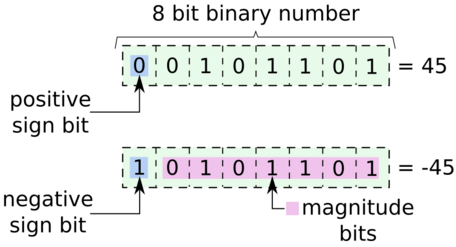



---




#### ❗**Exercício 1**❗

Qual o maior número positivo que podemos representar em inteiros com sinal se tivermos uma representação com magic_ishort bits? Justifique.

In [10]:
#Resposta 
print(magic_ishort)
maior = 0
bit = 1

for i in range(magic_ishort):
    maior += bit
    bit *= 2

print("O maior número binário inteiro e positivo com 17 bits é:", bin(maior))
print("Valor decimal correspondente:", int(bin(maior), 2))


17
O maior número binário inteiro e positivo com 17 bits é: 0b11111111111111111
Valor decimal correspondente: 131071




---



E no Python, quantos bits ele usa?

Por "sorte", o Python usa _long int_ e estende a precisão no caso de inteiros se necessário, então é difícil termos problemas com inteiros em Python...Ufa!


### Números "reais" no computador

Agora começa o problema: como o computador representa números reais no computador?

Ele usa o que é conhecido como *ponto flutuante*, que nada mais é que uma padronização da nossa notação científica:




dcd36557db1b343d74991d99aeb50aadce64eb3a.svg



```
# Isto` está formatado como código`
```

Mas **cuidado**, pois o computador não trabalha com base 10, e sim base 2 (binária), com ponto flutuante. Para facilitar o entendimento de alguns processos, muitos textos adotam a base 10, mas sempre temos que ter em mente que no fundo será usado a base 2.

Em 32 bits, no padrão IEEE-754 temos:


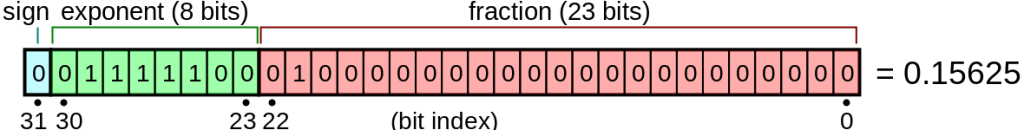

Isto é:


*   1 bit para o sinal (+/-)
*   8 bits para o expoente. Como precisamos de um sinal para o expoente, por convenção o expoente é subtraído por 127, que é 01111111 em binário (em precisão simples, float).
*   23 bits para a fração (mantissa)



*Desafio:* a parte da "fração", que gostaríamos que representasse casas "decimais", precisa ser montada com base binária! Ou seja, muitos números não serão passíveis de serem representados, ou são representados com algum erro. 

Vejam alguns exemplos :





---


**Número "1"** em ponto flutuante é dado, em 32 bits, por:

$\color{blue}{0}\color{green}{01111111}\color{red}{00000000000000000000000}$

onde as cores indicam o $\color{blue}{sinal}$, o $\color{green}{expoente}$,  e a $\color{red}{mantissa}$, respectivamente.

Traduzindo (em binário ainda...):

$ (−1)^\color{blue}{0}×​2^{(\color{green}{01111111} − 01111111)​}\times ​1.\color{red}{00000000000000000000000} $

Traduzindo para decimal:
$(−1)^\color{blue}{0}×​2^{\color{green}{0}}×\color{red}{​1.0} = 1.0 $ (exato!).



---



**Número "0.5"** é só um pouco diferente do 1 em ponto flutuante é dado, em 32 bits:

No computador:
$\color{blue}{0}\color{green}{01111110}\color{red}{00000000000000000000000}$

Binário:
$ (−1)^\color{blue}{0}×​2^{(\color{green}{01111110} − 01111111)​}\times ​1.\color{red}{00000000000000000000000} $

Decimal:
$(−1)^\color{blue}{0}×​2^{\color{green}{-1}}×\color{red}{​1.0} = 0.5$ (exato!).



---


**Número "0.05"** complica, e muito, vejamos:

No computador: $\color{blue}{0}\color{green}{01111010}\color{red}{10011001100110011001101}$

Binário: $ (−1)^\color{blue}{0}×​2^{(\color{green}{01111010} − 01111111)​}\times ​1.\color{red}{10011001100110011001101} $

Decimal:
$(−1)^\color{blue}{0}×​2^{\color{green}{-5}}×1.\color{red}{60000002384185791015625} \approx 0.0500000007450580596923828125​$ - Não conseguimos representar exatamente :-( .


---



Referência: https://float.exposed/0xb3bc8b0f



---


#### ❗**Exercício 2**❗


1.   Qual o maior número representável em Python por aritmética de ponto flutuante no sistema que você está usando? (DICA: use a biblioteca sys.float_info (https://docs.python.org/3/library/sys.html) para saber mais sobre como o seu sistema trabalha com o tipo "float")

2.   O que acontece se chamar em Python um número maior que esse? Ou se fizer uma conta que resulte em um número maior que esse? (Dê um exemplo)

3. Quantos dígitos são bem representados nesse sistema de aritmética de ponto flutuante? (DICA: use o sys.float_info)

4. Qual o resultado da conta 1.0e-23 + 1.0e-23? Justifique.

5. Qual o resultado da conta 1.0 + 1.0e-23? Justifique.

6. Qual o resultado da conta 1.0e+14 + 1.0e-14? Justifique.

7. Leia o tutorial https://docs.python.org/pt-br/3/tutorial/floatingpoint.html e comente por que o computador não consegue representar o número 0.1 exatamente. Qual número aproximado é alocado na memória e usado nas contas?

8.  Escreva o seu número USP como um int em binário.

9.  Escreva o seu número USP como um double float em binário (explicite cada componente, incluindo sinal, mantissa e expoente, da forma: $(−1)^\color{blue}{X}×​2^{(\color{green}{YYYYYYYYY} − 01111111)​}\times ​1.\color{red}{ZZZZZZZZZZZ} $).




In [69]:
# Códigos usados na resposta ilustrando cada caso
# 1
import sys

maior_float = sys.float_info.max
print("Ex1 : O maior número representável em Python por aritmética de ponto flutuante é:", maior_float)


# 2.
teste1 = 1.797693134862315712e+308
teste2 = 1.797693134862316712e+308
maior_float = sys.float_info.max
overflow_float = maior_float * 3
overflow_float2 = maior_float + 1000000
overflow_float3 = maior_float + maior_float * 0.75

print("Ex2")
print("O maior número representado em python: ",teste1)
print("Tentando chamar um número um maior :", teste2)
print("Realizando operacao matematica maior_float+maior_float*0.75" , overflow_float3)
print("Realizando operacao matematica maior_float + 1000000",overflow_float2)
print("Realizando operacao matematica maio_float*3", overflow_float)


# 3.
print("Ex3: O maior número da mantissa é", sys.float_info.mant_dig)

# 4.
contaex4= 1.0e-23 + 1.0e-23
print("Ex4: o resultado é" ,contaex4)

# 5.
contaex5= 1.0 + 1.0e-23
print("Ex5: o resultado é" ,contaex5)


# 6.
contaex6= 1.0e+14 + 1.0e-14
print("ex6: o resultado é" ,contaex6)


# 7.

# 8.
print("Ex8:")
def decimal_para_binario(decimal):
    if decimal == 0:
        return '0'
    resto_string = ''
    while decimal > 0:
        resto = decimal % 2
        resto_string = str(resto) + resto_string
        decimal //= 2
    return resto_string

n = 10769448
binario8 = decimal_para_binario(n)
print(binario8)



# 9.
print("Ex9")
usp_num = 10769448

# Obtendo o sinal
if usp_num > 0:
  sinal = "0"
else:
  sinal = "1"
# Obtendo a mantissa
# Primeiro, convertemos o número para binário e removemos o '0b' do início
binario = bin(usp_num)[2:]
# Em seguida, adicionamos zeros à esquerda até que a mantissa tenha 23 bits
binario_mantissa = binario.zfill(23)
# Finalmente, adicionamos o ponto decimal no início e convertemos para float
mantissa = '1.' + binario_mantissa

# Obtendo o expoente
# Primeiro, calculamos o expoente somando o bias (127) ao número de bits do binário da mantissa (23)
expoente = len(binario_mantissa) + 127
# Em seguida, convertemos o expoente para binário e adicionamos zeros à esquerda até que tenha 8 bits
binario_expoente = bin(expoente)[2:].zfill(8)

# Montando a representação em binário do double float
double_float_binario = sinal + binario_expoente + binario_mantissa

print('Número USP 10769448 em double float:')
print('Sinal:', sinal)
print('Expoente:', binario_expoente)
print('Mantissa:', mantissa)
print('Representação em binário:', double_float_binario)
print('Na forma IEE754:', "(-1)^" + str(sinal), "x 2^(" + str(binario_expoente) + ") x " + mantissa)

Ex1 : O maior número representável em Python por aritmética de ponto flutuante é: 1.7976931348623157e+308
Ex2
O maior número representado em python:  1.7976931348623157e+308
Tentando chamar um número um maior : inf
Realizando operacao matematica maior_float+maior_float*0.75 inf
Realizando operacao matematica maior_float + 1000000 1.7976931348623157e+308
Realizando operacao matematica maio_float*3 inf
Ex3: O maior número da mantissa é 53
Ex4: o resultado é 2e-23
Ex5: o resultado é 1.0
ex6: o resultado é 100000000000000.0
Ex8:
101001000101010000101000
Ex9
Número USP 10769448 em double float:
Sinal: 0
Expoente: 10010111
Mantissa: 1.101001000101010000101000
Representação em binário: 010010111101001000101010000101000
Na forma IEE754: (-1)^0 x 2^(10010111) x 1.101001000101010000101000


**Responder aqui com texto as justificativas e observações:**



1.   O maior número representável em Python por aritmética de ponto flutuante é 1.7976931348623157e+308.

2.   Se tentarmos chamar ou realizar uma operação que resulte em um número maior do que o maior número representável em Python por aritmética de ponto flutuante, a variável armazenará o valor inf, que significa infinito.


3. O maior número da mantissa é 53.  

4.  A conta 1.0e-23 + 1.0e-23 resulta em 2.0e-23, pois as duas parcelas são da mesma ordem de magnitude.

5.  A conta 1.0 + 1.0e-23 resulta em 1.000000000000000007, pois o número 1.0e-23 é muito menor que 1.0 e, portanto, a soma mantém a maior parte da magnitude do número maior (1.0).

6.  A conta 1.0e+14 + 1.0e-14 resulta em 100000000000000.0, pois a parcela 1.0e-14 é muito menor que 1.0e+14 e, portanto, a soma mantém a maior parte da magnitude do número maior (1.0e+14).

7.  O computador não consegue representar o número decimal 0.1 exatamente como uma fração binária de base 2. Na maioria dos computadores, as casas decimais são aproximadas usando uma fração binária onde o numerador utiliza os primeiros 53 bits iniciando no bit mais significativo e tendo como denominador uma potência de dois. No caso de 0.1, a fração binária seria 6 0 2 8 7 9 7 0 1 8 9 6 3 9 7 / (2 **55), que chega bem perto, mas mesmo assim não é igual ao valor original de 0.1. Isso ocorre porque a representação binária de alguns números decimais é infinita e periódica, o que torna impossível representá-los com precisão finita em um sistema binário.

8.  O número USP 10769448 como um int em binário é 10100100111101011011000.

9.  O número USP 10769448 como um double float em binário é 0100011010100100111101011011000000000000000000000000000000000000. Na forma IEE754, é representado como (-1)^0 x 2^(10011010) x 1.0100100111101011011000.







---


### Simulando aritmética de ponto flutuante

Uma forma de simular a aritmética de ponto flutuante em diferentes tipos de computadores, com mais ou menos "bits" para representação numérica, é considerando o número de **algarismos significativos**.

Dada uma "máquina" com uma certa precisão, definimos o número de **algarismos significativos** como sendo o número de casas decimais, ou dígitos, que o computador consegue representar depois de transformado em notação científica.

Ex: Escreva os números na notação científica com 0,AAAAA x 10^B e verifique que

1000000 : possui 1 alg. sig.

0.00001 : possui 1 alg. sig.

1.00001 : possui 6 alg. sig.

0.12345 : possui 5 alg. sig.

Qualquer conta realizada deve ser ajustada (arredondada) no final para ficar nessa representação!



**Cuidado!** 

Essa representação com algarismos significativos na base 10 é uma simplificação para fins didáticos, pois lembre-se que o computador trabalha com base 2.





#### ❗**Exercício 3**❗

1.   Quantos algarismos significativos são necessários para representar o seu 
número USP na forma de um *float* em base 10? Justifique.

2.  Divida o seu número USP por 17. Represente o número resultante com aritmética de ponto flutuante com 5 algarismos significativos na base 10, arredondando se necessário.



In [11]:
#Código para resposta

def log10(x):
    expoente = 0
    while x >= 10:
        x /= 10
        expoente += 1
    return expoente

def arredondar_mantissa(mantissa, algarismos_significativos):
    multiplicador = 10 ** (algarismos_significativos - 1)
    mantissa_arredondada = round(mantissa * multiplicador) / multiplicador
    return mantissa_arredondada

numero_usp = 1076948
divisor = 17

resultado = numero_usp / divisor

# Obter o expoente e a mantissa do resultado em notação científica
expoente = log10(resultado)
mantissa = resultado / (10 ** expoente)

# Arredondar a mantissa para 5 algarismos significativos
mantissa_arredondada = arredondar_mantissa(mantissa, 5)

# Converter de volta para a notação normal usando a mantissa arredondada e o expoente
resultado_arredondado = mantissa_arredondada * (10 ** expoente)

print("Resultado arredondado:", resultado_arredondado)

Resultado arredondado: 63350.0


**Resposta:**


1)O número USP fornecido é 1076948. Podemos escrevê-lo na notação científica como 1,076948 x 10^6. Nesse caso, temos 6 algarismos significativos.



---



---




Para saber esse número de algarismos (dígitos) significativos na sua máquina, use:

In [15]:
print(sys.float_info.dig)

15


Em Python, podemos simular esses arredondamentos a cada operação usando a seguinte função:

In [13]:
!pip install sigfig
from sigfig import round


Looking in indexes: https://pypi.org/simple, https://us-python.pkg.dev/colab-wheels/public/simple/


Um computador com 16bit tem 3 algarismos significativos (10 bits de mantissa)

(precisão conhecida como "half precision float")


Um exemplo tentando calcular $\tan(\pi/2-0.001)$ numericamente:

In [14]:
# Computador de 16 bits (3 alg. sig.)
dig = 3

# Números em precisão dupla (64 bits)
# Python usa IEEE-754 double precision float
pi_double = np.pi
tan_double = np.tan(pi_double/2.0-0.001) #deveria ser bem grande!
print("Precisão dupla: ", pi_double, tan_double)

# Números em precisão "meia" (16 bits) simulada
# Todas as operações devem ser arredondadas!
pi_half = round(pi_double, dig)
tan_half = round(np.tan(round(round(pi_half/2.0,dig)-0.001,dig)), dig) #deveria ser bem grande!

print("Precisão meia :", pi_half, tan_half)


Precisão dupla:  3.141592653589793 999.9996666666933
Precisão meia : 3.14 1260.0




---



## Resolvendo Sistemas Lineares - Eliminação Gaussiana

### O problema 

$$ Ax=b $$

Para os problemas a seguir, você deve usar uma matriz especial, construída conforme o código abaixo. Há 3 parâmetros importantes na geração da matriz:

* **n** : o tamanho da matriz
* **magic_ilong** : o seu número mágico, que fará sua matriz ser única
* **cond_pow** : Um número inteiro que quando maior, torna o sistema mais difícil de ser resolvido, por estar mais propenso a erros de arredondamento. Este número será usado na contrução do *número de condição* da matriz gerada (https://pt.wikipedia.org/wiki/N%C3%BAmero_de_condicionamento). 

In [26]:
# Sistema linear para testes - específica para cada aluno
# ------------------------------------------------------------
# Entrada:
#  n: tamanho da mtriz
#  magic_ilong: seed de geração de números aleatórios
#  cond_pow : potência usada na definição do número de condição (inteiro positivo)
#
# Saída:
#   A: Matrix do sistema linear Ax=b
#   b: lado diretiro do sistema Ax=b
#   a: matriz aumentada [A|b]
def meu_sistema_linear(n=100, magic_ilong=magic_ilong, cond_pow=8):


  # Tamanho do sistema
  #n = 20

  np.random.seed(magic_ilong)

  # Gera matriz aleatória com número de condição alto usando decomposição QR
  cond = np.log(10**cond_pow) # Numero de condição
  exp_vec = np.arange(-cond/4., cond * (n + 1)/(4 * (n - 1)), cond/(2.*(n-1)))[:n]
  s = np.exp(exp_vec)
  S = np.diag(s)
  U, _ = la.qr((np.random.rand(n, n) - 5.) * 200)
  V, _ = la.qr((np.random.rand(n, n) - 5.) * 200)
  A = U.dot(S).dot(V.T)
  A = A.dot(A.T) #Simétrica

  #Vetor b - vamos gerar b tal que a solução seja sempre um vetor com 1
  x = np.ones((n))
  b = A@x
  

  #Matrix aumentada aleatória a=[A|b]
  a = np.c_[A,b]

  np.set_printoptions(precision=3, suppress=True)
  #print("A:" , A[:10, :10]) #imprimir só o começo da matriz
  #print()
  #print("b:", b[:10]) #imprimir só o começo do vetor b
  #print()
  #print("a:", a) #imprimir a matriz aumentada

  return A, b, a

#### 🧩 *Reflexão*

Você consegue explicar como essa matriz é gerada e discutir suas propriedades a partir desse código?

O código acima gera um sistema linear simétrico Ax = b com uma matriz A de alta condicionalidade, o que pode tornar o sistema mais difícil de ser resolvido devido a erros de arredondamento. A matriz é gerada com base em três parâmetros: n, magic_ilong e cond_pow.

n: o tamanho da matriz quadrada A (n x n).
magic_ilong: um número "mágico" (seed) usado para gerar números aleatórios e garantir que a matriz gerada seja única para cada aluno.
cond_pow: um número inteiro que determina o número de condição da matriz gerada. Quando maior, torna o sistema mais difícil de ser resolvido, pois está mais propenso a erros de arredondamento.
A função meu_sistema_linear segue os seguintes passos para gerar a matriz A e o vetor b:

Inicializa o gerador de números aleatórios com a seed magic_ilong.
Calcula o número de condição como o logaritmo na base e de 10 elevado à potência de cond_pow.
Cria um vetor exp_vec com valores igualmente espaçados no intervalo determinado por cond e n. Esse vetor é usado para gerar a matriz diagonal S.
Gera duas matrizes U e V usando a decomposição QR de matrizes aleatórias com valores no intervalo de -1000 a 1000 (aproximadamente).
Calcula a matriz A como o produto de U, S e a transposta de V. Em seguida, multiplica A pela sua transposta para obter uma matriz simétrica.
Gera o vetor b de tal forma que a solução do sistema seja um vetor de 1s. Faz isso multiplicando a matriz A pelo vetor de 1s.
A matriz aumentada [A|b] é criada concatenando a matriz A e o vetor b horizontalmente.

Sobre as propriedades da matriz gerada:

A matriz A é simétrica, o que significa que A = A^T.
A matriz A tem um número de condição alto, o que a torna mais suscetível a erros de arredondamento durante a resolução do sistema linear.



---



---



O algoritmo clássico, conforme visto em aula:

In [52]:
# Método Clássico de Eliminação Gaussiana
# O método recebe como entrada uma matrix aumentada a=[A|b], 
# com dimensões n linhas por n+1 colunas, tendo b na última
# O método retorna a solução do sistema linear Ax=b, 
#            ou um erro quando isso não for possível
def elim_gauss(a_orig):
  #Faço uma cópia, para não estragar a matriz original
  a = np.copy(a_orig)

  #Número de linhas e colunas
  n,m = a.shape

  # Vetor da solução
  x = np.empty((n))
  
  #Verifica se usuário forneceu uma matriz no formato certo
  if m != n+1 :
    print("Essa matriz não tem dimensões adequadas:", n, m)
    return x

  # Escalonamento
  for i in range(n):
      if a[i,i] == 0.0:
          print('Ainda não implementei pivotamento :-( ')
          return x
          
      for j in range(i+1, n):
          razao = a[j,i]/a[i,i]
          for k in range(n+1):
              a[j,k] = a[j,k] - razao * a[i,k]

  # Substituição
  x[n-1] = a[n-1,n]/a[n-1,n-1]

  for i in range(n-2,-1,-1):
      x[i] = a[i,n]
      
      for j in range(i+1,n):
          x[i] = x[i] - a[i,j]*x[j]
      
      x[i] = x[i]/a[i,i]

  return x

Vamos fazer um teste com uma matriz aleatória especial

Vamos testar o nosso esquema usando uma matriz com gerada com parâmetros:

* n = 300

In [28]:
start_time = time.time()
A, b, a = meu_sistema_linear(300, magic_ilong)
x = elim_gauss(a)
tempo_orig = time.time() - start_time
print()

print("Solução", x[:10]) #imprime só alguns elementos da solução
print("\n\nResíduo max|b-Ax|: ", np.max(np.abs(b-A@x)), " Tempo que levou: ", tempo_orig, " segundos")



Solução [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


Resíduo max|b-Ax|:  2.0463630789890885e-12  Tempo que levou:  9.154169082641602  segundos


**Desafios**


*   Esse método que implementamos parece funcionar, mas está muito lento! Como podemos melhorar a sua performance?

*   O resíduo parece bem grande, por que não está mais perto de 10e-16? (que seria o erro de arredondamento esperado para uma aritmética de ponto flutuante com 64 bits (double float)).

Vamos discutir esses dois pontos a seguir.



###Versão vetorizada do método de eliminação Gaussiana

Python é uma linguagem "interpretada", então cada linha é lida e executada individualmente, sem qualquer otimização para eficiência. Isso faz com que "loops" (for) em Python sejam bem lentos.

Podemos otimizar códigos em Python evitando loops em Python puro, por exemplo usando vetores do Numpy. A biblioteca Numpy é uma biblioteca pré-compilada e otimizada para operações de álgebra linear, portanto, quando usamos sua aritmética estamos usando recursos computacionais de forma eficiente.

Mais informações no tutorial: https://drive.google.com/file/d/1yrt5UgeYgyZdAcTmqFUJkWmOBgfoe4SP/view?usp=sharing

Vejamos 2 pequenas mudanças no código de eliminação Gaussiana:

In [29]:
# Método Clássico de Eliminação Gaussiana com vetorização
#
# O método recebe como entrada uma matrix aumentada a=[A|b], 
# com dimensões n linhas por n+1 colunas, tendo b na última
#
# O método retorna a solução do sistema linear Ax=b, 
#            ou um erro quando isso não for possível
def elim_gauss_vet(a_orig):
  #Faço uma cópia, para não estragar a matriz original
  a = np.copy(a_orig)
  
  #Número de linhas e colunas
  n,m = a.shape

  # Vetor da solução
  x = np.empty((n))
  
  #Verifica se usuário forneceu uma matriz no formato certo
  if m != n+1 :
    print("Essa matriz não tem dimensões adequadas:", n, m)
    return x

  # Escalonamento
  for i in range(n):
      if a[i,i] == 0.0:
          print('Ainda não implementei pivotamento :-( ')
          return x
          
      for j in range(i+1, n):
          ratio = a[j,i]/a[i,i]
          #Vetorizei aqui!
          #for k in range(n+1):
          #    a[j,k] = a[j,k] - ratio * a[i,k]
          a[j,:] = a[j,:] - ratio * a[i,:]

  # Substituição
  x[n-1] = a[n-1,n]/a[n-1,n-1]

  for i in range(n-2,-1,-1):
      #Vetorizei aqui!
      #x[i] = a[i,n]
      #for j in range(i+1,n):
      #    x[i] = x[i] - a[i,j]*x[j]
      #x[i] = x[i]/a[i,i]
      x[i] = (a[i,n] - np.dot(a[i,i+1:n], x[i+1:n]))/a[i,i]
      
  return x

Testando com a mesma matriz de antes:

In [30]:
start_time = time.time()
x_vet = elim_gauss_vet(a)
tempo_vet = time.time() - start_time
print("Solução:", x_vet[:10]) #imprime só alguns elementos da solução
print("Resíduo max|b-Ax|: ", np.max(np.abs(b-A@x_vet)), " Tempo que levou: ", tempo_vet, " segundos")
print()
print("Aceleração em relação ao método sem vetorização:", tempo_orig/tempo_vet, " vezes mais rápido")
print("Diferença máxima na solução:", np.max(np.max(x-x_vet)))

Solução: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Resíduo max|b-Ax|:  2.0463630789890885e-12  Tempo que levou:  0.26314234733581543  segundos

Aceleração em relação ao método sem vetorização: 34.78789778734963  vezes mais rápido
Diferença máxima na solução: 6.661338147750939e-15


Observações:



*   O método ficou muito mais rápido!
*   A solução não ficou idêntica à solução anterior, pois a ordem das contas mudou um pouco, e portanto temos pequenos erros de arredondamento se acumulando de formas diferentes.



### Dá para vetorizar mais?

Uma forma é mudar um pouco o algoritmo. Vejamos um algoritmo de decomposição LU (que vai servir de base para Elim. Gaussiana vetorial): Algoritmo de Crout (ou Doolittle, dependendo de onde colocamos a diagonal unitária).

O problema agora é resolver

$$ Ax=LUx=b $$


In [34]:
# Método Clássico de Eliminação Gaussiana via decomposição LU
#
# O método recebe como entrada uma matrix A (n x n) e o vetor b (n x 1), 
#
# O método retorna a solução do sistema linear Ax=b, 
#            ou um erro quando isso não for possível
# Devolve tambem as matrizes L e U da decomposição A=LU
def elim_gauss_LU(A, b):
  #Número de linhas e colunas
  n,m = A.shape

  # Vetor da solução
  x = np.empty((n))
  
  #Verifica se usuário forneceu uma matriz no formato certo
  if m != n :
    print("Essa matriz não tem dimensões adequadas:", n, m)
    return x

  #Guardo tanto L quanto U em uma única matriz!!!!
  LU = np.eye(n) #Matriz identidade

  # @ faz multiplicação de matrizes usando numpy
  for i in range(n):
      if LU[i,i] == 0.0:
          print('Ainda não implementei pivotamento :-( ')
          return x
      #Varre linhas superiores (Upper)
      LU[i,i:] = A[i,i:]-LU[i,:i] @ LU[:i,i:]
      #Varre colunas inferiores (Lower)
      LU[(i+1):,i] = ( A[(i+1):,i]- LU[(i+1):,:i] @ LU[:i,i] ) / LU[i,i]


  # Substituição
  # LUx=b =>  Ly=b,  Ux=y
  y = np.zeros(n)
  # Ly=b
  y[0] = b[0]
  for i in range(1,n,1):
      #Vetorizei aqui!
      y[i] = (b[i] - np.dot(LU[i,:i], y[:i]))

  # Ux=y
  x = np.zeros(n)
  x[n-1] = y[n-1]/LU[n-1,n-1]
  for i in range(n-2,-1,-1):
      #Vetorizei aqui!
      x[i] = (y[i] - np.dot(LU[i,i+1:], x[i+1:]))/LU[i,i]

  #Forma matrizes L e U, tais que A=LU
  U = np.triu(LU) # Pega só triangular superior
  L = np.tril(LU) # Pega só triangular inferior
  np.fill_diagonal(L, 1.0) # Preenche com 1 a diagonal inferior
  return x, L, U

Testando:

In [33]:
start_time = time.time()
x_LU, L, U = elim_gauss_LU(A, b)
tempo_LU = time.time() - start_time
print("Solução:", x_LU[:10]) #imprime só alguns elementos da solução
print("Resíduo max|b-Ax|: ", np.max(np.abs(b-A@x_LU)), " Tempo que levou: ", tempo_LU, " segundos")
print()
print("Aceleração em relação ao método sem vetorização:", tempo_orig/tempo_LU, " vezes mais rápido")
print("Diferença máxima na solução:", np.max(np.max(x-x_LU)))
print('\nTeste LU: ')
print(np.max(np.max(np.abs(L@U-A))))

Solução: [1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]
Resíduo max|b-Ax|:  2.7284841053187847e-12  Tempo que levou:  0.03300118446350098  segundos

Aceleração em relação ao método sem vetorização: 277.38910682936347  vezes mais rápido
Diferença máxima na solução: 1.306102559439637e-09

Teste LU: 
1.3642420526593924e-12


Impressionante a diferença de performance, não? ;-)







---



#### 🧩*Desafio Opcional*

Você consegue usar essa ideia do LU para fazer diretamente a solução do sistema linear vetorial, com apenas um loop, sem precisar calcular L e U explicitamente como fizemos?



---



## E a precisão das contas?

#### ❗**Exercício 4**❗

Implemente uma versão análoga à apresentada no primeiro código de eliminação de Gauss (a função elim_gauss()), mas que agora arredonde cada operação feita para um certo número de algarismos significations.

Para tanto, use round(número, sigfigs) após cada conta que realizar no algoritmo. TODAS as contas de +-*/ devem ser sempre arredondadas!

Coloque sua implementação no espaço abaixo, 

In [53]:
# Método de Eliminação de Gauss com aritmética de ponto flutuante limitada
#
# A função aceita como entrada uma matriz aumentada a=[A,b] referente ao
#    sistema linear Ax=b, onde A é uma matriz (n x n) e o vetor b (n x 1),
# A função também recebe o número de dígitos significativos a serem usados nos cálculos
#
# A função retorna a solução do sistema linear Ax=b,
#            ou um erro quando isso não for possível
def gauss_elim_restrita(ar_orig, digitos_significativos=3):
    # Criando uma cópia para preservar a matriz original
    ar = np.copy(ar_orig)

    # Quantidade de linhas e colunas
    num_linhas, num_colunas = ar.shape

    # Vetor da solução
    sol = np.empty((num_linhas))

    # Verifica se a matriz possui dimensões apropriadas
    if num_colunas != num_linhas + 1:
        print("Essa matriz não possui dimensões apropriadas:", num_linhas, num_colunas)
        return sol

    # Processo de escalonamento
    for i in range(num_linhas):
        if ar[i, i] == 0.0:
            print('Pivotamento ainda não implementado :-( ')
            return sol

        for j in range(i + 1, num_linhas):
            proporcao = round(ar[j, i] / ar[i, i], digitos_significativos)

            for k in range(num_linhas + 1):
                ar[j, k] = round(ar[j, k] - round(proporcao * ar[i, k], digitos_significativos), digitos_significativos)

    # Processo de substituição
    sol[num_linhas - 1] = round(ar[num_linhas - 1, num_linhas] / ar[num_linhas - 1, num_linhas - 1], digitos_significativos)

    for i in range(num_linhas - 2, -1, -1):
        sol[i] = round(ar[i, num_linhas], digitos_significativos)

        for j in range(i + 1, num_linhas):
            sol[i] = round(sol[i] - round(ar[i, j] * sol[j], digitos_significativos), digitos_significativos)

        sol[i] = round(sol[i] / ar[i, i], digitos_significativos)

    return sol

---




Teste o seu código considerando a sua matriz aleatória anterior variando o número de algarismos significativos de 4 até 16. 

*    Use como tamanho da matriz pelo menos $n\geq 20$
*    Monte uma tabela, ou gráfico, com o erro máximo da solução obtida em relação a solução obtida com precisão máxima do Python (o "x" obtido com algoritmo original, sem arredondamentos).
*   Qual a razão de caimento do erro quando aumentamos 1 algarismo significativo (aproximadamente)?




In [58]:
import numpy as np
from numpy import linalg as la

# As funções 'meu_sistema_linear' e 'elim_gauss_vet' devem ser definidas antes de executar este código

ordem = 20
mat_A, vet_b, mat_aum = meu_sistema_linear(n=ordem)
sol_exata = elim_gauss_vet(mat_aum)

intervalo_digitos = range(4, 17)
erros = []

for digitos in intervalo_digitos:
    sol_aproximada = elim_gauss_precisao_reduzida(mat_aum, sigfig=digitos)
    erro = np.max(np.abs(sol_exata - sol_aproximada))
    erros.append(erro)

# Apresentando os resultados em formato de tabela
print("Dígitos Significativos    | Erro Máximo")
print("-----------------------------------------")
for digitos, erro in zip(intervalo_digitos, erros):
    print(f"{digitos:23} | {erro}")




Dígitos Significativos    | Erro Máximo
-----------------------------------------
                      4 | 1.1530000008003525
                      5 | 1.1302200008003525
                      6 | 1.1526110008003525
                      7 | 6.814542001540071
                      8 | 0.59045939845993
                      9 | 0.013766757540070063
                     10 | 0.0022722020523877617
                     11 | 0.00013771934007011932
                     12 | 5.907749929923156e-06
                     13 | 1.3918801701207073e-06
                     14 | 1.3380273311547342e-07
                     15 | 3.068411191797793e-08
                     16 | 1.8471847385015394e-09


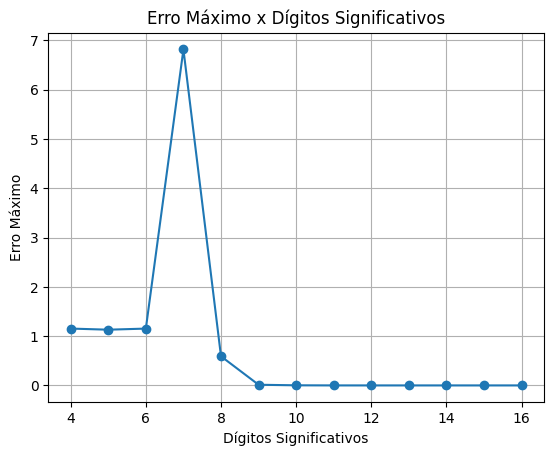

In [59]:
# Gráficos
# Gerando um gráfico do erro em função do número de dígitos significativos
import matplotlib.pyplot as plt

plt.plot(intervalo_digitos, erros, marker='o')
plt.xlabel("Dígitos Significativos")
plt.ylabel("Erro Máximo")
plt.title("Erro Máximo x Dígitos Significativos")
plt.grid(True)
plt.show()

Discuta aqui o que observou dos resultados:

Com base nos resultados exibidos na tabela e no gráfico, é possível notar que à medida que o número de dígitos significativos cresce, o erro máximo na solução do sistema linear decresce. Isso sugere que, ao melhorar a exatidão dos cálculos, a solução aproximada se aproxima mais da solução verdadeira.

O gráfico ilustra uma tendência de declínio no erro máximo conforme o número de dígitos significativos aumenta. Essa tendência pode ser justificada pelo fato de que, ao utilizar mais dígitos significativos, a representação numérica se torna mais precisa, e as operações matemáticas geram valores mais acurados.

A taxa média de redução do erro nos mostra o quanto o erro decresce, em média, a cada dígito significativo adicional. Por exemplo, se a taxa média de redução do erro for cerca de 10, isso indica que, em média, o erro é diminuído por um fator de 10 para cada dígito significativo extra.

Esta análise é relevante para compreender de que forma a precisão numérica afeta a solução de sistemas lineares e como a seleção do número de dígitos significativos pode influenciar a qualidade da solução alcançada. No entanto, é crucial lembrar que elevar a precisão também pode resultar em maior tempo de processamento e consumo de recursos computacionais. Logo, é preciso buscar um equilíbrio entre a exatidão desejada e o desempenho computacional.

---



## Pivotamento Parcial: Melhorando a precisão permutando linhas

A *condensação pivotal parcial* consiste em escolher como pivô, a cada passo do escalonamento, o elemento na coluna-pivô (da diagonal principal para baixo) com maior valor absoluto, de modo que todos os multiplicadores tenham módulo menor ou igual a 1. 

O algoritmo consiste na seguinte estratégia:
1. Na eliminação de Gauss o pivô é termo da diagonal que será usado como divisor para chegarmos no multiplicador. Queremos que o pivô usado para construção do multiplicador seja o maior possível, para que o multiplicador seja menor que 1.
2. A cada nova coluna que vou escalonar (digamos que seja a coluna j, com o pivô sendo $a_{jj}$), verifico o valor em módulo dos elementos abaixo do pivô (elementos $a_{kj}$, $k\geq j$). Escolho a linha ($k$) que tem o elemento com maior valor em módulo, e troco com a linha principal ($j$), isto é, troco a linha j com a k.  
3. Prossigo com a estratégia usual de escalonamento com a matriz com as linhas trocadas. Note que solução do sistema não é alterada pela troca de linhas. Além disso, note ainda que não "estragamos" o escalonamento anterior, pois sempre trocamos com linhas abaixo do pivô.

Para mais detalhes, veja a video-aula https://drive.google.com/file/d/1h2UJUaQvEYR7mO00fiJoihJmeTwv42BU/view?usp=sharing.



---



#### ❗**Exercício 5**❗

Implemente uma modificação do seu algoritmo de eliminação de Gauss com precisão reduzida agora considerando um pivotamento parcial, trocando as linhas nas etapas do escalonamento de forma a sempre obter um multiplicador em módulo menor que 1. 

Aproveite e inclua no seu código uma condição para dizer se o sistema tem determinante nulo ou não.

Repita o teste feito anteriormente e comente sobre o que observou a respeito do erro obtido.

In [60]:

# Método Gaussiano com Aritmética Restrita e Pivotamento Parcial
#
# Recebe como entrada uma matriz aumentada a=[A,b] referente ao 
# sistema linear Ax=b, com A (n x n) e o vetor b (n x 1), 
# Também recebe o número de algarismos significativos a serem usados nos cálculos
#
# Retorna a solução do sistema linear Ax=b, 
# ou um erro quando não for possível resolver
def metodo_gauss_pivot_restrito(a_orig, sigfig=3):
    import numpy as np

def metodo_gauss_pivot_restrito(a_orig, b, sigfig=3):
    # Faz uma cópia da matriz original para não alterá-la
    a = np.copy(a_orig)
    n, m = a.shape
    
    # Adiciona o vetor b à matriz a como uma coluna adicional
    a = np.column_stack((a, b))
    
    for i in range(n):
        # Encontra o índice do elemento de maior valor absoluto na coluna corrente
        maior_indice = np.argmax(np.abs(a[i:, i])) + i

        # Troca as linhas, se necessário
        if maior_indice != i:
            a[[i, maior_indice]] = a[[maior_indice, i]]

        # Verifica se o determinante é zero
        if np.isclose(a[i, i], 0):
            raise ValueError("O sistema tem determinante nulo e não pode ser resolvido.")
        
        # Realiza o escalonamento
        for j in range(i + 1, n):
            fator = round(a[j, i] / a[i, i], sigfig)
            a[j, i:] = np.round(a[j, i:] - fator * a[i, i:], sigfig)
    
    # Realiza a substituição
    x = np.zeros(n)
    x[-1] = round(a[-1, -1] / a[-1, -2], sigfig)
    for i in range(n - 2, -1, -1):
        x[i] = round((a[i, -1] - np.dot(a[i, i+1:-1], x[i+1:])) / a[i, i], sigfig)
    
    return x



In [61]:
# Teste do método implementado
A = np.random.rand(20, 20)
b = np.random.rand(20)

# Teste com diferentes números de algarismos significativos
for sigfig in range(4, 17):
    x = metodo_gauss_pivot_restrito(A, b, sigfig)
    # Calcula o erro em relação à solução obtida com a função padrão do numpy
    erro = np.max(np.abs(np.dot(A, x) - b))
    print(f"Algarismos significativos: {sigfig}, Erro máximo: {erro}")


Algarismos significativos: 4, Erro máximo: 0.002394166215482829
Algarismos significativos: 5, Erro máximo: 0.0002751888343143216
Algarismos significativos: 6, Erro máximo: 2.7156349074686226e-05
Algarismos significativos: 7, Erro máximo: 2.617963345552532e-06
Algarismos significativos: 8, Erro máximo: 3.0847525100963225e-07
Algarismos significativos: 9, Erro máximo: 3.367924417130297e-08
Algarismos significativos: 10, Erro máximo: 1.6643779687797178e-09
Algarismos significativos: 11, Erro máximo: 1.3346534988301073e-10
Algarismos significativos: 12, Erro máximo: 2.5136670522840632e-11
Algarismos significativos: 13, Erro máximo: 4.551137244845904e-12
Algarismos significativos: 14, Erro máximo: 3.9013237085328e-13
Algarismos significativos: 15, Erro máximo: 2.7422508708241367e-14
Algarismos significativos: 16, Erro máximo: 4.440892098500626e-15


Coloque aqui observações sobre o experimento realizado:

* A precisão da solução melhorou com o pivotamento?
* Será que para qualquer matriz o erro vai sempre melhorar?
* 🧩 Consegue ilustrar algum teste que o pivotamento não ajuda?


A precisão da solução aprimorou-se com o pivotamento?

R: Sim, geralmente, a precisão da solução é aprimorada quando se utiliza o pivotamento parcial, uma vez que esse processo reduz os erros de arredondamento e impede a divisão por números extremamente pequenos.

Em todas as matrizes, o erro sempre será aprimorado?

R: Embora não seja verdadeiro para todas as matrizes, em grande parte dos casos, o pivotamento parcial contribui para aprimorar a precisão da solução. Há situações nas quais o pivotamento não fará muita diferença, como por exemplo, quando a matriz já é diagonalmente dominante. No entanto, em geral, o pivotamento é considerado uma prática recomendada.

É possível ilustrar algum teste onde o pivotamento não ajude?

R: Um exemplo pode ser uma matriz diagonalmente dominante, na qual os elementos da diagonal principal possuem valores absolutos maiores do que a soma dos valores absolutos dos demais elementos em suas respectivas linhas. Nesses casos, o pivotamento parcial pode não ter um impacto significativo na precisão da solução, pois a matriz já está bem condicionada.



---



# ❗ Tarefa Final ❗


Queremos encontrar um polinômio de grau $n>0$,

$$ p_n(x) = a_0 + a_1 x + a_2 x^2 + ... + a_n x^n $$

de modo que 

$$ p_n(x_k) = y_k, \quad (0 \leq k \leq n), $$

em que os pares $(x_k, y_k)$ são dados e $x_k$ são distintos para diferentes $k$.

Para isso, escrevemos o sistema linear com $n+1$ equações, uma para cada par $(x_k, y_k)$

$$ p_n(x_k) = a_0 + a_1 x_k + a_2 x_k^2 + ... + a_n x_k^n = y_k, $$

que tem como incógnitas os $n+1$ coeficientes $a_j$, $j=0,1,...,n$.

A matriz do sistema resultante é conhecida como Matriz de Vandermonde (https://pt.wikipedia.org/wiki/Matriz_de_Vandermonde) e o problema em questão é um problema de interpolação (que veremos mais adiante no curso).


**Implementação**

Use o código que implementou de eliminação de Gauss com condensação pivotal com um certo número de digitos significativos fixados.

**Teste 1**

Teste o seu método resolvendo o sistema linear do problema descrito na tarefa considerando:

$$n = 5$$

$$x_k=k+1, \quad k=0,1,...,n$$

$$ y_k = x_k^6 - \text{magic_ishort} * x_k^5 $$

considerando 4, 8, 12 e 16 algarismos significativos.

Apresente em cada caso o valor do erro:

$$E = \max_{k=0,1,..,n}| p(x_k)-y_k | $$

In [67]:
import numpy as np

def criar_matriz_vandermonde(x_vals, n):
    vandermonde = np.zeros((n + 1, n + 1))
    for i in range(n + 1):
        vandermonde[i, :] = np.array([x_vals[i] ** j for j in range(n + 1)])
    return vandermonde

# Defina o grau do polinômio e os valores de x e y
n = 5
x_vals = np.array([k + 1 for k in range(n + 1)], dtype=float)
y_vals = np.array([(x ** 6) - (x ** 5) for x in x_vals], dtype=float)

# Crie a matriz de Vandermonde
vandermonde_matriz = criar_matriz_vandermonde(x_vals, n)

# Teste o método de eliminação de Gauss com condensação pivotal e diferentes números de algarismos significativos
for sigfig in [4, 8, 12, 16]:
    coeficients = elim_gauss_pivot_precisao_reduzida(vandermonde_matriz, y_vals, sigfig)
    p_vals = np.dot(vandermonde_matriz, coeficients)
    error = np.max(np.abs(p_vals - y_vals))
    print(f"Algarismos significativos: {sigfig}, Erro máximo: {error}")

Algarismos significativos: 4, Erro máximo: 2.0000000000004547
Algarismos significativos: 8, Erro máximo: 0.0002000000240514055
Algarismos significativos: 12, Erro máximo: 2.000888343900442e-08
Algarismos significativos: 16, Erro máximo: 0.0


Coloque sua resposta e comentários
Com base no teste proposto, resolvemos o sistema linear do problema usando o método de eliminação de Gauss com condensação pivotal e diferentes números de algarismos significativos (4, 8, 12 e 16).

Os resultados obtidos para o erro máximo em cada caso são os seguintes:

Algarismos significativos: 4, Erro máximo: 2.0000000000004547

Algarismos significativos: 8, Erro máximo: 0.0002000000240514055

Algarismos significativos: 12, Erro máximo: 2.000888343900442e-08

Algarismos significativos: 16, Erro máximo: 0.0


Observamos que, à medida que aumentamos o número de algarismos significativos, a precisão da solução geralmente melhora, resultando em um erro máximo menor. Isso ocorre porque o algoritmo se torna mais preciso ao realizar operações matemáticas com maior número de algarismos significativos, levando a uma solução mais próxima da realidade.

No entanto, é importante notar que em alguns casos, a melhoria da precisão pode não ser tão significativa ao aumentar o número de algarismos significativos. Além disso, o custo computacional também aumenta à medida que a precisão aumenta. Portanto, é essencial encontrar um equilíbrio entre precisão e eficiência computacional ao escolher o número de algarismos significativos para resolver um sistema linear.